In [1]:
import os
import sys
lib_path = os.path.abspath(os.path.join(os.path.abspath(''), 'functions/'))
sys.path.append(lib_path)
# need to append our functions dir to the path! 

import SD_raster_loading
import SD_NC_loading
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dalecLoad
import spectralConv
import seaborn as sns
import scipy as sp
from datetime import timedelta
import matplotlib.dates as mdates

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import median_absolute_error, mean_absolute_error

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV

In [2]:
def MAE(true, pred):
    return np.sum(np.abs(true - pred))/len(pred)
def MAPE(true, pred):
    return 100 * np.sum(np.abs((true - pred)/true))/len(pred)
def RMSE(true, pred):
    return np.sqrt(np.sum((true - pred)**2)/len(pred))

def RMSD(y_true, y_est):
    '''
    logspace RMSE
    '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**(np.sqrt(np.mean((y_true - y_est)**2)))-1

def MAD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the mean absolute difference (MAD) '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**np.mean(np.abs(y_true - y_est))-1

def MAvD(y_true, y_est):
    '''mean average differnce - bias'''
    return np.sum((y_est - y_true)/len(y_est))

def MAPD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median absolute percentage difference (MAPD) '''
    return np.nanmedian(np.abs((y_true - y_est) / y_true)) * 100


def MDSA(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median symmetric accuracy (MdSA) '''
    return (np.exp(np.nanmedian(np.abs(np.log(y_est / y_true)))) - 1) * 100


def SSPB(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the symmetric signed percentage bias (SSPB) '''
    med = np.nanmedian( np.log(y_est / y_true) )
    return np.sign(med) * (np.exp(np.abs(med)) - 1) * 100

def MRD(true, pred):
    '''mean relative difference'''
    return np.sum(((pred - true)/true)) / len(pred)

def P_BIAS(true, pred):
    'percent bias'
    return 100*np.nanmean((true - pred)/np.abs(true))

In [3]:
coord = [56.147005, -3.923311] # this is approx the location of the DALEC + ~10 m out which looks less edge effected 
# coord = [56.147005, -3.923147] # this is approx the location of the DALEC + ~20 m out which looks less edge effected 

#coord = [56.14693897799395, -3.923458784671348] # this is approx the location of the DALEC
#coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
SD_SR = SD_NC_loading.load_multiple_SDs('planetData/full_SR/ncfiles/snap/ncfiles/',
                                                coord, skipSameDay=False,
                                                pixel_grid_shape=(10,10),
                                                filetype=".nc",
                                                variable='',
                                                wavelengths_planet=[444, 492, 533, 566, 612,
                                                                    666, 707, 866, np.nan, np.nan],
                                                div_by_pi=False,
                                                planet_SR_date=True,
                                                datetime_format="%Y:%m:%d %H:%M:%S",
                                                u_int_16=True)

are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? -

are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? -

are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? -

are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? -

are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? -

are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? -

are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? -

are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? - best double check it!
coastal_blue : 444
blue : 492
green_i : 533
green : 566
yellow : 612
red : 666
rededge : 707
nir : 866
lat : nan
lon : nan
are you sure you know the wavelength order? -

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

In [4]:
SD_SR

rho_s_48_80 rho_s_48_81 rho_s_48_82  \
Date                Wavelength                                       
2020-04-07 10:35:46 444.0         0.006729    0.006256    0.006241   
                    492.0         0.006653    0.006638    0.006485   
                    533.0         0.007645    0.007706     0.00734   
                    566.0         0.007004    0.007004    0.006943   
                    612.0         0.007324    0.007126    0.006592   
...                                    ...         ...         ...   
2024-04-08 11:33:14 666.0         0.009598    0.009476    0.009491   
                    707.0         0.011704    0.012131    0.012314   
                    866.0         0.019623    0.020218    0.018616   
                    NaN           0.000857    0.000857    0.000857   
                    NaN           -0.00006    -0.00006    -0.00006   

                               rho_s_48_83 rho_s_48_84 rho_s_48_85  \
Date                Wavelength                                       
2020-04-07 10:35:46 444.0         0.006699    0.006561    0.006638   
                    492.0         0.006653    0.006683    0.006699   
                    533.0         0.006775    0.006806    0.007126   
                    566.0         0.006897     0.00676    0.006714   
                    612.0         0.006607    0.006455    0.006271   
...                                    ...         ...         ...   
2024-04-08 11:33:14 666.0         0.009537    0.009659    0.009506   
                    707.0           0.0121    0.012009    0.011627   
                    866.0         0.017884    0.018967    0.018311   
                    NaN           0.000857    0.000857    0.000857   
                    NaN           -0.00006    -0.00006    -0.00006   

                               rho_s_48_86 rho_s_48_87 rho_s_48_88  \
Date                Wavelength                                       
2020-04-07 10:35:46 444.0         0.007431    0.006531    0.006439   
                    492.0         0.006577    0.005951    0.005997   
                    533.0         0.007172    0.006912    0.006912   
                    566.0          0.00676    0.006531    0.006714   
                    612.0         0.006119    0.006455     0.00676   
...                                    ...         ...         ...   
2024-04-08 11:33:14 666.0         0.009384    0.009598    0.010163   
                    707.0         0.011292    0.011582    0.011933   
                    866.0         0.017823    0.017929    0.018036   
                    NaN           0.000857    0.000857    0.000857   
                    NaN           -0.00006    -0.00006    -0.00006   

                               rho_s_48_89  ... rho_s_57_80 rho_s_57_81  \
Date                Wavelength              ...                           
2020-04-07 10:35:46 444.0         0.006744  ...    0.006912    0.006821   
                    492.0         0.006165  ...     0.00647    0.006363   
                    533.0         0.006729  ...    0.006943    0.006912   
                    566.0         0.006928  ...    0.006943    0.006714   
                    612.0         0.006912  ...    0.006607     0.00679   
...                                    ...  ...         ...         ...   
2024-04-08 11:33:14 666.0          0.00972  ...    0.009079    0.009262   
                    707.0         0.011246  ...    0.010697    0.010285   
                    866.0          0.01828  ...    0.018036    0.016907   
                    NaN           0.000857  ...    0.000857    0.000857   
                    NaN           -0.00006  ...    -0.00006    -0.00006   

                               rho_s_57_82 rho_s_57_83 rho_s_57_84  \
Date                Wavelength                                       
2020-04-07 10:35:46 444.0         0.006653    0.006958     0.00679   
                    492.0         0.006271    0.006577    0.006683   
                    533.0         0.006912

In [5]:
# useful for interrogating the ncdf file (eg. to find the name we want to use for the date)
f = netCDF4.Dataset('planetData/full_SR/ncfiles/snap/ncfiles/20201119_103352_21_2235_3B_AnalyticMS_SR_8b_clip.nc')
# SD_spect = get_SD_NC_Spectra_grid(f, coord[0], coord[1], shape=pixel_grid_shape,
#                                   variable=variable, wavelengths=wavelengths)
f

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    Conventions: CF-1.4
    TileSize: 512:512
    dimensions(sizes): y(204), x(298)
    variables(dimensions): uint16 coastal_blue(y, x), uint16 blue(y, x), uint16 green_i(y, x), uint16 green(y, x), uint16 yellow(y, x), uint16 red(y, x), uint16 rededge(y, x), uint16 nir(y, x), float64 lat(y, x), float64 lon(y, x)
    groups: Metadata_Group

In [6]:
pd.to_datetime('2020:04:07 10:35:46', format="%Y:%m:%d %H:%M:%S")

Timestamp('2020-04-07 10:35:46')

In [7]:
f.groups['Metadata_Group'].groups['Image_info'].TIFFTAG_DATETIME

'2020:11:19 10:33:52'

In [5]:
SD_acolite = SD_NC_loading.load_multiple_SDs('planetData/acolite_output_L2W/',
                                             coord, skipSameDay=False, pixel_grid_shape=(10,10),
                                             filetype="L2W.nc",
                                             variable='Rrs',
                                             div_by_pi=False,)

# have changed from using L2W to L2R
# this means we don't need to mess with the automatic land masking
# Doesn't seem to affect results at all as far as I can tell!
# I was trying to get past the land mask anyway by changing the threshold, so let's just not bother!

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

In [9]:
SD_acolite

rho_s_48_80  rho_s_48_81   rho_s_48_82  \
Date                      Wavelength                                            
2020-04-07 10:35:46+00:00 444.0       0.0062590363  0.005292565   0.005210826   
                          492.0       0.0070090564   0.00693613  0.0066565373   
                          533.0        0.009481409  0.009570106   0.008771527   
                          566.0        0.008273239  0.008260297   0.008130853   
                          612.0        0.008991937  0.008530757  0.0074041425   
...                                            ...          ...           ...   
2024-04-08 11:33:14+00:00 566.0        0.008131984  0.008306543   0.008231736   
                          612.0         0.00887178   0.00825753   0.007341924   
                          666.0        0.007870666  0.007557961  0.0075851567   
                          707.0        0.014096508  0.015103846  0.0155927725   
                          866.0        0.033745393   0.03525252    0.03155849   

                                       rho_s_48_83   rho_s_48_84  \
Date                      Wavelength                               
2020-04-07 10:35:46+00:00 444.0       0.0062590363  0.0059052827   
                          492.0        0.007021207  0.0070941215   
                          533.0       0.0075787054  0.0076929787   
                          566.0         0.00805318   0.007755373   
                          612.0        0.007431306  0.0071189157   
...                                            ...           ...   
2024-04-08 11:33:14+00:00 566.0        0.008007279   0.008493525   
                          612.0       0.0067659314   0.006648073   
                          666.0         0.00773472   0.008060964   
                          707.0        0.015175762   0.014873686   
                          866.0         0.02954211   0.032178212   

                                       rho_s_48_85   rho_s_48_86  \
Date                      Wavelength                               
2020-04-07 10:35:46+00:00 444.0        0.006068575   0.007753638   
                          492.0       0.0071305768  0.0068632043   
                          533.0        0.008340258   0.008429067   
                          566.0        0.007651771   0.007755373   
                          612.0       0.0067249103  0.0064395103   
...                                            ...           ...   
2024-04-08 11:33:14+00:00 566.0        0.008979498   0.008543385   
                          612.0        0.007498951   0.007943713   
                          666.0       0.0077075292  0.0074083717   
                          707.0        0.014024516   0.013117004   
                          866.0         0.03074461    0.02944508   

                                       rho_s_48_87   rho_s_48_88  \
Date                      Wavelength                               
2020-04-07 10:35:46+00:00 444.0       0.0058236183   0.005673875   
                          492.0       0.0055128327   0.005622405   
                          533.0        0.007896096  0.0078834025   
                          566.0       0.0072502024   0.007651771   
                          612.0        0.007078161   0.007757182   
...                                            ...           ...   
2024-04-08 11:33:14+00:00 566.0        0.008082105   0.008144457   
                          612.0        0.007472781   0.006045434   
                          666.0       0.0078162905   0.009201962   
                          707.0        0.013822916   0.014715418   
                          866.0        0.029716745   0.029968943   

                                       rho_s_48_89  ...   rho_s_57_80  \
Date                      Wavelength                ...                 
2020-04-07 10:35:46+00:00 444.0        0.006286244  ...  0.0066533918   
                          492.0       0.0059510376  ...    0.00662006   
                          533.0       

In [6]:
SD_acolite = SD_acolite.reset_index()
SD_acolite['date'] = SD_acolite.Date.dt.date
SD_SR = SD_SR.reset_index()
SD_SR['date'] = SD_SR.Date.dt.date

In [7]:
pd.to_datetime(SD_acolite.Date, utc=False)

0      2020-04-07 10:35:46+00:00
1      2020-04-07 10:35:46+00:00
2      2020-04-07 10:35:46+00:00
3      2020-04-07 10:35:46+00:00
4      2020-04-07 10:35:46+00:00
                  ...           
2691   2024-04-08 11:33:14+00:00
2692   2024-04-08 11:33:14+00:00
2693   2024-04-08 11:33:14+00:00
2694   2024-04-08 11:33:14+00:00
2695   2024-04-08 11:33:14+00:00
Name: Date, Length: 2696, dtype: datetime64[ns, UTC]

In [8]:
SD_SR.Date = pd.to_datetime(SD_SR.Date, utc=True)

In [9]:
# load list of good files from data review csv...
good_df = pd.read_csv('planetData/good_data_review.csv')
extra_good = good_df.copy()
# select everything except images with cloud cover
extra_good = good_df.copy()[good_df['flag'] != 'cloud']
extra_bad = good_df.copy()[good_df['flag'] == 'cloud']


# uncomment this line for selection of only 'good' images
#extra_good = good_df.copy()[good_df['atmospheric interference at measurement points'] == 'good']

good_files = []
for f in extra_good.filename:
    #good_files.append(f[1:5] + '_' + f[5:7] + '_' + f[7:9] + '_' + f[10:12]+ '_' + f[12:14]+ '_' + f[14:16])
    good_files.append(f[1:16])
    
bad_files = []
for f in extra_bad.filename:
    #good_files.append(f[1:5] + '_' + f[5:7] + '_' + f[7:9] + '_' + f[10:12]+ '_' + f[12:14]+ '_' + f[14:16])
    bad_files.append(f[1:16])

good_dates_UTC = pd.to_datetime(good_files, format='%Y%m%d_%H%M%S', utc=True)
good_dates = pd.to_datetime(good_files, format='%Y%m%d_%H%M%S', utc=False)
bad_dates_UTC = pd.to_datetime(bad_files, format='%Y%m%d_%H%M%S', utc=True)
bad_dates = pd.to_datetime(bad_files, format='%Y%m%d_%H%M%S', utc=False)




In [10]:
# remove bad dates
# SD_df = SD_df[SD_df.Date.isin(good_dates)]
SD_SR = SD_SR[~SD_SR.Date.isin(bad_dates_UTC)]
SD_acolite = SD_acolite[~SD_acolite.Date.isin(bad_dates_UTC)]

In [11]:
extra_good['Date'] = good_dates
extra_good['Sat_ID'] = [f[20:24] for f in extra_good.filename]

extra_good_UTC = extra_good.copy()
extra_good_UTC['Date'] = good_dates_UTC

In [12]:
SD_SR = SD_SR.merge(extra_good_UTC[['Date', 'Sat_ID']], on='Date', how='left')
SD_acolite = SD_acolite.merge(extra_good_UTC[['Date', 'Sat_ID']], on='Date', how='left')

In [13]:
SD_acolite.columns

Index(['Date', 'Wavelength', 'rho_s_48_80', 'rho_s_48_81', 'rho_s_48_82',
       'rho_s_48_83', 'rho_s_48_84', 'rho_s_48_85', 'rho_s_48_86',
       'rho_s_48_87',
       ...
       'rho_s_57_82', 'rho_s_57_83', 'rho_s_57_84', 'rho_s_57_85',
       'rho_s_57_86', 'rho_s_57_87', 'rho_s_57_88', 'rho_s_57_89', 'date',
       'Sat_ID'],
      dtype='object', length=104)

In [14]:
SD_SR_melt = pd.melt(SD_SR, id_vars=['Date', 'date', 'Wavelength', 'Sat_ID'],
                   var_name='location', value_name='Rrs')
SD_acolite_melt = pd.melt(SD_acolite, id_vars=['Date', 'date', 'Wavelength', 'Sat_ID'],
                   var_name='location', value_name='Rrs')

In [15]:
SD_SR_melt

,Date,date,Wavelength,Sat_ID,location,Rrs
0,2020-04-07 10:35:46+00:00,2020-04-07,444.0,NaN,rho_s_48_80,0.006729
1,2020-04-07 10:35:46+00:00,2020-04-07,492.0,NaN,rho_s_48_80,0.006653
2,2020-04-07 10:35:46+00:00,2020-04-07,533.0,NaN,rho_s_48_80,0.007645
3,2020-04-07 10:35:46+00:00,2020-04-07,566.0,NaN,rho_s_48_80,0.007004
4,2020-04-07 10:35:46+00:00,2020-04-07,612.0,NaN,rho_s_48_80,0.007324
...,...,...,...,...,...,...
333995,2024-04-08 11:33:14+00:00,2024-04-08,666.0,NaN,rho_s_57_89,0.00972
333996,2024-04-08 11:33:14+00:00,2024-04-08,707.0,NaN,rho_s_57_89,0.011124
333997,2024-04-08 11:33:14+00:00,2024-04-08,866.0,NaN,rho_s_57_89,0.01738
333998,2024-04-08 11:33:14+00:00,2024-04-08,NaN,NaN,rho_s_57_89,0.000857


In [16]:
SD_acolite_melt

,Date,date,Wavelength,Sat_ID,location,Rrs
0,2020-04-07 10:35:46+00:00,2020-04-07,444.0,NaN,rho_s_48_80,0.0062590363
1,2020-04-07 10:35:46+00:00,2020-04-07,492.0,NaN,rho_s_48_80,0.0070090564
2,2020-04-07 10:35:46+00:00,2020-04-07,533.0,NaN,rho_s_48_80,0.009481409
3,2020-04-07 10:35:46+00:00,2020-04-07,566.0,NaN,rho_s_48_80,0.008273239
4,2020-04-07 10:35:46+00:00,2020-04-07,612.0,NaN,rho_s_48_80,0.008991937
...,...,...,...,...,...,...
267195,2024-04-08 11:33:14+00:00,2024-04-08,566.0,NaN,rho_s_57_89,0.0066467994
267196,2024-04-08 11:33:14+00:00,2024-04-08,612.0,NaN,rho_s_57_89,0.007158693
267197,2024-04-08 11:33:14+00:00,2024-04-08,666.0,NaN,rho_s_57_89,0.008128916
267198,2024-04-08 11:33:14+00:00,2024-04-08,707.0,NaN,rho_s_57_89,0.012713405


In [17]:
SD_SR_melt

,Date,date,Wavelength,Sat_ID,location,Rrs
0,2020-04-07 10:35:46+00:00,2020-04-07,444.0,NaN,rho_s_48_80,0.006729
1,2020-04-07 10:35:46+00:00,2020-04-07,492.0,NaN,rho_s_48_80,0.006653
2,2020-04-07 10:35:46+00:00,2020-04-07,533.0,NaN,rho_s_48_80,0.007645
3,2020-04-07 10:35:46+00:00,2020-04-07,566.0,NaN,rho_s_48_80,0.007004
4,2020-04-07 10:35:46+00:00,2020-04-07,612.0,NaN,rho_s_48_80,0.007324
...,...,...,...,...,...,...
333995,2024-04-08 11:33:14+00:00,2024-04-08,666.0,NaN,rho_s_57_89,0.00972
333996,2024-04-08 11:33:14+00:00,2024-04-08,707.0,NaN,rho_s_57_89,0.011124
333997,2024-04-08 11:33:14+00:00,2024-04-08,866.0,NaN,rho_s_57_89,0.01738
333998,2024-04-08 11:33:14+00:00,2024-04-08,NaN,NaN,rho_s_57_89,0.000857


In [18]:
subset = ['Date', 'date', 'Wavelength', 'location', 'Rrs']

In [19]:
SD_acolite_melt

,Date,date,Wavelength,Sat_ID,location,Rrs
0,2020-04-07 10:35:46+00:00,2020-04-07,444.0,NaN,rho_s_48_80,0.0062590363
1,2020-04-07 10:35:46+00:00,2020-04-07,492.0,NaN,rho_s_48_80,0.0070090564
2,2020-04-07 10:35:46+00:00,2020-04-07,533.0,NaN,rho_s_48_80,0.009481409
3,2020-04-07 10:35:46+00:00,2020-04-07,566.0,NaN,rho_s_48_80,0.008273239
4,2020-04-07 10:35:46+00:00,2020-04-07,612.0,NaN,rho_s_48_80,0.008991937
...,...,...,...,...,...,...
267195,2024-04-08 11:33:14+00:00,2024-04-08,566.0,NaN,rho_s_57_89,0.0066467994
267196,2024-04-08 11:33:14+00:00,2024-04-08,612.0,NaN,rho_s_57_89,0.007158693
267197,2024-04-08 11:33:14+00:00,2024-04-08,666.0,NaN,rho_s_57_89,0.008128916
267198,2024-04-08 11:33:14+00:00,2024-04-08,707.0,NaN,rho_s_57_89,0.012713405


In [20]:
SD_SR_med = SD_SR_melt.drop(['location'], axis=1).groupby([#'Date',
                                                           'date',
                                                           'Wavelength', 'Sat_ID']).median()
SD_SR_med.rename(columns={'Rrs':'Planet_SR'}, inplace=True)
SD_SR_med = SD_SR_med.dropna().reset_index()

SD_acolite_med = SD_acolite_melt.drop(['location'], axis=1).groupby([#'Date',
                                                                     'date',
                                                                     'Wavelength', 'Sat_ID']).median()
SD_acolite_med.rename(columns={'Rrs':'Acolite'}, inplace=True)
SD_acolite_med = SD_acolite_med.reset_index()

In [21]:
SD_SR_med

,date,Wavelength,Sat_ID,Date,Planet_SR
0,2022-04-19,444.0,2276,2022-04-19 10:47:12+00:00,0.005859
1,2022-04-19,492.0,2276,2022-04-19 10:47:12+00:00,0.004654
2,2022-04-19,533.0,2276,2022-04-19 10:47:12+00:00,0.004929
3,2022-04-19,566.0,2276,2022-04-19 10:47:12+00:00,0.005997
4,2022-04-19,612.0,2276,2022-04-19 10:47:12+00:00,0.005692
...,...,...,...,...,...
643,2023-10-11,566.0,2459,2023-10-11 10:31:23+00:00,0.003952
644,2023-10-11,612.0,2459,2023-10-11 10:31:23+00:00,0.004005
645,2023-10-11,666.0,2459,2023-10-11 10:31:23+00:00,0.0037
646,2023-10-11,707.0,2459,2023-10-11 10:31:23+00:00,0.004669


In [144]:
SD_SR_med[SD_SR_med.Wavelength==444]

,date,Wavelength,Sat_ID,Date,Planet_SR,original_date,date_flag
0,2022-04-19,444.0,2276,2022-04-19 10:47:12+00:00,0.005859,nan,0
8,2022-04-23,444.0,2453,2022-04-23 10:26:58+00:00,0.004883,nan,0
16,2022-04-24,444.0,2407,2022-04-24 11:16:56+00:00,0.00753,nan,0
24,2022-04-29,444.0,2416,2022-04-29 11:13:04+00:00,0.006134,nan,0
32,2022-05-24,444.0,2402,2022-05-24 11:21:07+00:00,0.006546,nan,0
...,...,...,...,...,...,...,...
608,2023-09-11,444.0,24b2,2023-09-11 10:30:46+00:00,0.011597,nan,0
616,2023-09-12,444.0,2415,2023-09-12 10:32:01+00:00,0.005982,nan,0
617,2023-09-12,444.0,2475,2023-09-12 11:11:16+00:00,0.005142,nan,0
632,2023-09-30,444.0,2483,2023-10-01 11:10:51+00:00,0.006806,2023-10-01,1


In [171]:
SD_ac_unmelt = SD_acolite_med.pivot(columns='Wavelength', values='Acolite', index='Date').reset_index()
SD_ac_unmelt

Wavelength,Date,444.0,492.0,533.0,566.0,612.0,666.0,707.0,866.0
0,2022-04-19 10:47:12+00:00,0.007421,0.005071,0.005571,0.007712,0.007146,0.006194,0.010346,0.016509
1,2022-04-23 10:26:58+00:00,0.004736,0.003659,0.003456,0.004397,0.003209,0.002823,0.005805,0.009715
2,2022-04-24 11:16:56+00:00,0.005851,0.005588,0.004662,0.006393,0.003566,0.005922,0.007681,0.012783
3,2022-04-29 11:13:04+00:00,0.004571,0.004348,0.006751,0.009116,0.007098,0.005073,0.009616,0.017488
4,2022-05-24 11:21:07+00:00,0.007271,0.007987,0.012673,0.016768,0.010785,0.007756,0.015576,0.015178
...,...,...,...,...,...,...,...,...,...
76,2023-09-11 10:30:46+00:00,0.016762,0.008372,0.011636,0.016225,0.017232,0.008883,0.021766,0.047072
77,2023-09-12 10:32:01+00:00,0.006528,0.007851,0.011266,0.013475,0.01128,0.008145,0.011409,0.018563
78,2023-09-12 11:11:16+00:00,0.007993,0.009412,0.012554,0.0143,0.011574,0.00991,0.012575,0.016521
79,2023-10-01 11:10:51+00:00,0.005138,0.003809,0.004682,0.004847,0.005012,0.003592,0.006089,0.0116


In [179]:
def chla_OC3(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2424, b=-2.2146,
             c=1.5193, d=-0.7702,
             e=-0.4291, returnX=False):
    '''3 band NASA alg (model M in claire neil paper)'''

    X = np.log10(np.array(np.max([df[Rrs_444],
                                  df[Rrs_492]],
                                 axis=0)/(df[Rrs_566]), dtype=float))

    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))

In [180]:
def something(df, a=1):
    return a

q = 1
something(q, a=2)

2

In [181]:
def OC3_linear_SD(df, filetype='l2w', b=-2.63150769, a=0.76734456):
    if filetype == 'l2w':
        X = chla_OC3(df,
                        returnX=True)
    elif filetype == 'l2r':
        X = chla_OC3(df, Rrs_444='rhos_444', Rrs_492='rhos_492',
                         Rrs_533='rhos_533', Rrs_566='rhos_566',
                        returnX=True
                       )
    return 10**(b*X + a)

In [182]:
SD_OC3_ac_lin_coeff = {'b':-2.91864966, 'a':0.65474659}

(-0.0055, 0.01)

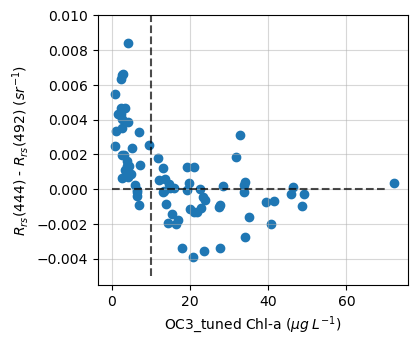

In [230]:
fig, ax = plt.subplots(1, 1, figsize=(4,3.5))
chla_ac_oc3 = chla_OC3(SD_ac_unmelt, Rrs_444=444.0,
         Rrs_492=492.0, Rrs_566=566.0,
         c=0, d=0, e=0, **SD_OC3_ac_lin_coeff,
         )

Rrs_444_diff_492 = SD_ac_unmelt[444.0] - SD_ac_unmelt[492.0]

plt.scatter(chla_ac_oc3, Rrs_444_diff_492)
plt.plot([0, 70], [0, 0], 'k--', alpha=0.7)
plt.plot([10, 10], [-0.005, 0.01], 'k--', alpha=0.7)

plt.xlabel('OC3_tuned Chl-a ($\mu g \: L^{-1}$)')
plt.ylabel('$R_{rs}$(444) - $R_{rs}$(492) ($sr^{-1}$)')
plt.grid(alpha=0.5)
ax.set_ylim(-0.0055, 0.01)
# plt.gca().set_xscale('log')


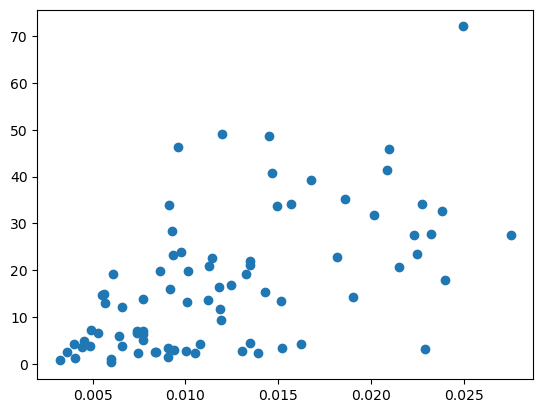

In [227]:
plt.scatter(SD_ac_unmelt[566.0], chla_ac_oc3)

In [228]:
sum(chla_ac_oc3<10)
pct_low = sum(Rrs_444_diff_492[chla_ac_oc3<20]>0)/sum(chla_ac_oc3<20)
print('percentage of low chl-a (< 20 ug/L) where Rrs_444>Rrs492 = ' + str(pct_low*100))

pct_high = sum(Rrs_444_diff_492[chla_ac_oc3>=20]>0)/sum(chla_ac_oc3>=20)
print('percentage of high chl-a (>= 20 ug/L) where Rrs_444>Rrs492 = ' + str(pct_high*100))


percentage of low chl-a (< 20 ug/L) where Rrs_444>Rrs492 = 73.58490566037736
percentage of high chl-a (>= 20 ug/L) where Rrs_444>Rrs492 = 28.57142857142857


In [24]:
SD_SR_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   date        648 non-null    object             
 1   Wavelength  648 non-null    float64            
 2   Sat_ID      648 non-null    object             
 3   Date        648 non-null    datetime64[ns, UTC]
 4   Planet_SR   648 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), object(3)
memory usage: 25.4+ KB


In [25]:
dalec_SD = pd.read_csv('DALEC_SD_bands_2022_23.csv')
dalec_SD.drop(['Unnamed: 0', 'month', 'year', 'Date'], axis=1, inplace=True)
dalec_SD.rename(columns={'Rrs':'Rrs_DALEC', 'wavelength':'Wavelength'}, inplace=True)
dalec_SD = dalec_SD.groupby(['Wavelength', 'date']).median().reset_index()
dalec_SD

,Wavelength,date,Rrs_DALEC
0,444.0,2022-07-28,0.003432
1,444.0,2022-07-31,0.003935
2,444.0,2022-08-01,0.003738
3,444.0,2022-08-02,0.003542
4,444.0,2022-08-03,0.002927
...,...,...,...
763,866.0,2023-09-26,0.003964
764,866.0,2023-09-27,0.003757
765,866.0,2023-09-28,0.002344
766,866.0,2023-09-29,0.001369


In [26]:
for SD_med in [SD_SR_med, SD_acolite_med]:
    SD_med.date = pd.to_datetime(SD_med.date)
    SD_med['original_date'] = 'nan'
    SD_med['date_flag'] = 0

    SD_med.loc[SD_med.date=='2023-10-01', 'original_date'] = '2023-10-01'
#     SD_med.loc[SD_med.date=='2022-08-17', 'original_date'] = '2022-08-17'
#     SD_med.loc[SD_med.date=='2023-09-03', 'original_date'] = '2023-09-03'

    SD_med.loc[SD_med.date=='2023-10-01', 'date_flag'] = 1
#     SD_med.loc[SD_med.date=='2022-08-17', 'date_flag'] = 1
#     SD_med.loc[SD_med.date=='2023-09-03', 'date_flag'] = 1

    SD_med.loc[SD_med.date=='2023-10-01', 'date'] = pd.to_datetime('2023-09-30')
#     SD_med.loc[SD_med.date=='2022-08-17', 'date'] = pd.to_datetime('2022-08-15')
#     SD_med.loc[SD_med.date=='2023-09-03', 'date'] = pd.to_datetime('2023-09-01')

<Axes: xlabel='Wavelength', ylabel='Acolite'>

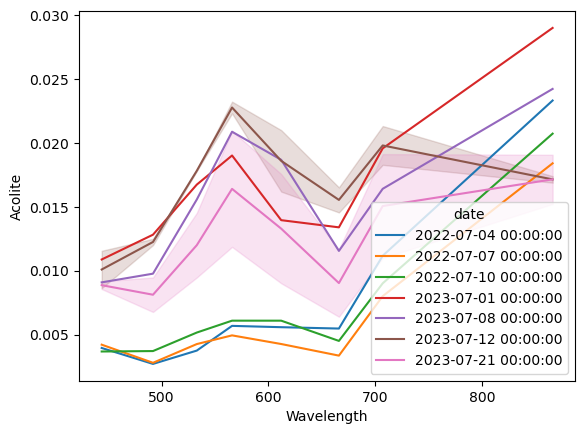

In [143]:
sns.lineplot(data=SD_acolite_med[(SD_acolite_med.date.dt.month.isin([7]))],
             x='Wavelength', y='Acolite', hue='date', legend=True)
# plt.ylim(0.002, 0.007)
# plt.xlim(400, 750)

In [28]:
dalec_SD['date'] = pd.to_datetime(dalec_SD.date)
SD_SR_med['date'] = pd.to_datetime(SD_SR_med.date)
SD_acolite_med['date'] = pd.to_datetime(SD_acolite_med.date)

dalec_sd = dalec_SD.merge(SD_acolite_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_sd

,Wavelength,date,Rrs_DALEC,Sat_ID,Date,Acolite,original_date,date_flag
10,444.0,2022-08-10,0.004061,2432,2022-08-10 10:27:06+00:00,0.004927,nan,0.0
11,444.0,2022-08-11,0.003798,2427,2022-08-11 10:28:22+00:00,0.004054,nan,0.0
13,444.0,2022-08-13,0.003795,227a,2022-08-13 11:13:41+00:00,0.005004,nan,0.0
16,444.0,2023-07-08,0.001222,242d,2023-07-08 10:29:51+00:00,0.009086,nan,0.0
20,444.0,2023-07-12,0.000402,248c,2023-07-12 11:05:26+00:00,0.011559,nan,0.0
...,...,...,...,...,...,...,...,...
776,866.0,2023-09-08,0.002888,2438,2023-09-08 11:10:07+00:00,0.030064,nan,0.0
779,866.0,2023-09-11,0.001588,24b2,2023-09-11 10:30:46+00:00,0.047072,nan,0.0
780,866.0,2023-09-12,0.000951,2415,2023-09-12 10:32:01+00:00,0.018563,nan,0.0
781,866.0,2023-09-12,0.000951,2475,2023-09-12 11:11:16+00:00,0.016521,nan,0.0


In [29]:
SD_SR_med

,date,Wavelength,Sat_ID,Date,Planet_SR,original_date,date_flag
0,2022-04-19,444.0,2276,2022-04-19 10:47:12+00:00,0.005859,nan,0
1,2022-04-19,492.0,2276,2022-04-19 10:47:12+00:00,0.004654,nan,0
2,2022-04-19,533.0,2276,2022-04-19 10:47:12+00:00,0.004929,nan,0
3,2022-04-19,566.0,2276,2022-04-19 10:47:12+00:00,0.005997,nan,0
4,2022-04-19,612.0,2276,2022-04-19 10:47:12+00:00,0.005692,nan,0
...,...,...,...,...,...,...,...
643,2023-10-11,566.0,2459,2023-10-11 10:31:23+00:00,0.003952,nan,0
644,2023-10-11,612.0,2459,2023-10-11 10:31:23+00:00,0.004005,nan,0
645,2023-10-11,666.0,2459,2023-10-11 10:31:23+00:00,0.0037,nan,0
646,2023-10-11,707.0,2459,2023-10-11 10:31:23+00:00,0.004669,nan,0


In [30]:
dalec_sd = dalec_sd.merge(SD_SR_med, on=['date', 'Wavelength',
                                         'date_flag', 'original_date', 'Sat_ID', 'Date'],
                          how='left').dropna()

In [31]:
dalec_sd.iloc[:10]

,Wavelength,date,Rrs_DALEC,Sat_ID,Date,Acolite,original_date,date_flag,Planet_SR
0,444.0,2022-08-10,0.004061,2432,2022-08-10 10:27:06+00:00,0.004927,nan,0.0,0.003288
1,444.0,2022-08-11,0.003798,2427,2022-08-11 10:28:22+00:00,0.004054,nan,0.0,0.002983
2,444.0,2022-08-13,0.003795,227a,2022-08-13 11:13:41+00:00,0.005004,nan,0.0,0.006851
3,444.0,2023-07-08,0.001222,242d,2023-07-08 10:29:51+00:00,0.009086,nan,0.0,0.01062
4,444.0,2023-07-12,0.000402,248c,2023-07-12 11:05:26+00:00,0.011559,nan,0.0,0.010208
5,444.0,2023-07-12,0.000402,24bf,2023-07-12 10:31:47+00:00,0.008626,nan,0.0,0.00985
6,444.0,2023-07-21,0.000420,24b3,2023-07-21 10:34:38.500000+00:00,0.009167,nan,0.0,0.003952
7,444.0,2023-07-21,0.000420,24c4,2023-07-21 10:35:46+00:00,0.008564,nan,0.0,0.004257
8,444.0,2023-08-26,0.000646,2477,2023-08-26 11:06:48+00:00,0.008854,nan,0.0,0.011292
9,444.0,2023-08-31,0.000586,248f,2023-08-31 11:11:38.500000+00:00,0.0136,nan,0.0,0.011978


In [32]:
dalec_sd.Acolite = dalec_sd.Acolite.astype(float)
dalec_sd.Planet_SR = dalec_sd.Planet_SR.astype(float)

In [33]:
dalec_sd

,Wavelength,date,Rrs_DALEC,Sat_ID,Date,Acolite,original_date,date_flag,Planet_SR
0,444.0,2022-08-10,0.004061,2432,2022-08-10 10:27:06+00:00,0.004927,nan,0.0,0.003288
1,444.0,2022-08-11,0.003798,2427,2022-08-11 10:28:22+00:00,0.004054,nan,0.0,0.002983
2,444.0,2022-08-13,0.003795,227a,2022-08-13 11:13:41+00:00,0.005004,nan,0.0,0.006851
3,444.0,2023-07-08,0.001222,242d,2023-07-08 10:29:51+00:00,0.009086,nan,0.0,0.010620
4,444.0,2023-07-12,0.000402,248c,2023-07-12 11:05:26+00:00,0.011559,nan,0.0,0.010208
...,...,...,...,...,...,...,...,...,...
139,866.0,2023-09-08,0.002888,2438,2023-09-08 11:10:07+00:00,0.030064,nan,0.0,0.015480
140,866.0,2023-09-11,0.001588,24b2,2023-09-11 10:30:46+00:00,0.047072,nan,0.0,0.024582
141,866.0,2023-09-12,0.000951,2415,2023-09-12 10:32:01+00:00,0.018563,nan,0.0,0.010369
142,866.0,2023-09-12,0.000951,2475,2023-09-12 11:11:16+00:00,0.016521,nan,0.0,0.008629


In [34]:
dalec_sd_melt = dalec_sd.melt(id_vars=['Rrs_DALEC', 'Wavelength', 'date',
                                       'date_flag', 'original_date', 'Date', 'Sat_ID'],
                              value_vars=['Acolite', 'Planet_SR'],
                              var_name='Algorithm', value_name='Rrs',)

In [156]:
Rrs_444 = dalec_sd_melt[(dalec_sd_melt.Wavelength==444) & \
                        (dalec_sd_melt.Algorithm == 'Acolite')].reset_index()

dalec_sd_unmelt = dalec_sd_melt[['Wavelength', 'Rrs']].pivot(columns='Wavelength', values='Rrs')
dalec_sd_unmelt
# dalec_sd_melt[dalec_sd_melt.Wavelength==492].Rrs.reset_index() - dalec_sd_melt[dalec_sd_melt.Wavelength==444].Rrs.reset_index()

Wavelength,444.0,492.0,533.0,566.0,612.0,666.0,707.0,866.0
0,0.004927,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.004054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.005004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.009086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.011559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
283,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015480
284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.024582
285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010369
286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008629


In [162]:
dalec_sd_melt[dalec_sd_melt.Algorithm=='Acolite'][['Wavelength', 
                                                   'Rrs',
                                                   'Date']].pivot(columns='Wavelength',
                                                                         values='Rrs',
                                                                         index='Date',).reset_index()

Wavelength,Date,444.0,492.0,533.0,566.0,612.0,666.0,707.0,866.0
0,2022-08-10 10:27:06+00:00,0.004927,0.004717,0.007519,0.009259,0.006467,0.005688,0.010958,0.015894
1,2022-08-11 10:28:22+00:00,0.004054,0.005200,0.007642,0.008645,0.006886,0.006472,0.011392,0.020355
2,2022-08-13 11:13:41+00:00,0.005004,0.005298,0.008470,0.011996,0.009157,0.006426,0.014245,0.023870
3,2023-07-08 10:29:51+00:00,0.009086,0.009766,0.015575,0.020883,0.018684,0.011549,0.016414,0.024238
4,2023-07-12 10:31:47+00:00,0.008626,0.012004,0.017831,0.022321,0.021009,0.016526,0.021329,0.017406
5,2023-07-12 11:05:26+00:00,0.011559,0.012494,0.017818,0.023240,0.016195,0.014564,0.018290,0.016894
6,2023-07-21 10:34:38.500000+00:00,0.009167,0.009467,0.014527,0.020954,0.017570,0.011666,0.019130,0.019080
7,2023-07-21 10:35:46+00:00,0.008564,0.006767,0.009468,0.011864,0.009015,0.006394,0.010996,0.015229
8,2023-08-26 11:06:48+00:00,0.008854,0.012762,0.016729,0.021497,0.014845,0.012441,0.017153,0.017429
9,2023-08-31 11:11:38.500000+00:00,0.013600,0.012241,0.013772,0.013501,0.008369,0.008370,0.011173,0.017211


In [154]:
dalec_sd_melt

,Rrs_DALEC,Wavelength,date,date_flag,original_date,Date,Sat_ID,Algorithm,Rrs,Multiple_overpass_day
0,0.004061,444.0,2022-08-10,0.0,nan,2022-08-10 10:27:06+00:00,2432,Acolite,0.004927,False
1,0.003798,444.0,2022-08-11,0.0,nan,2022-08-11 10:28:22+00:00,2427,Acolite,0.004054,False
2,0.003795,444.0,2022-08-13,0.0,nan,2022-08-13 11:13:41+00:00,227a,Acolite,0.005004,False
3,0.001222,444.0,2023-07-08,0.0,nan,2023-07-08 10:29:51+00:00,242d,Acolite,0.009086,False
4,0.000402,444.0,2023-07-12,0.0,nan,2023-07-12 11:05:26+00:00,248c,Acolite,0.011559,True
...,...,...,...,...,...,...,...,...,...,...
283,0.002888,866.0,2023-09-08,0.0,nan,2023-09-08 11:10:07+00:00,2438,Planet_SR,0.015480,False
284,0.001588,866.0,2023-09-11,0.0,nan,2023-09-11 10:30:46+00:00,24b2,Planet_SR,0.024582,False
285,0.000951,866.0,2023-09-12,0.0,nan,2023-09-12 10:32:01+00:00,2415,Planet_SR,0.010369,True
286,0.000951,866.0,2023-09-12,0.0,nan,2023-09-12 11:11:16+00:00,2475,Planet_SR,0.008629,True


In [36]:
duplicate_days = dalec_sd_melt.Date.unique()[pd.Series(dalec_sd_melt.Date.unique().date).duplicated(keep=False)]

In [37]:
dalec_sd_melt['Multiple_overpass_day'] = False

In [38]:
dalec_sd_melt.loc[dalec_sd_melt.Date.isin(duplicate_days), 'Multiple_overpass_day'] = True

In [39]:
dalec_sd_melt[(dalec_sd_melt['Wavelength']==666) & (dalec_sd_melt['Algorithm']=='Acolite')]

,Rrs_DALEC,Wavelength,date,date_flag,original_date,Date,Sat_ID,Algorithm,Rrs,Multiple_overpass_day
90,0.005282,666.0,2022-08-10,0.0,nan,2022-08-10 10:27:06+00:00,2432,Acolite,0.005688,False
91,0.005393,666.0,2022-08-11,0.0,nan,2022-08-11 10:28:22+00:00,2427,Acolite,0.006472,False
92,0.007132,666.0,2022-08-13,0.0,nan,2022-08-13 11:13:41+00:00,227a,Acolite,0.006426,False
93,0.011963,666.0,2023-07-08,0.0,nan,2023-07-08 10:29:51+00:00,242d,Acolite,0.011549,False
94,0.008809,666.0,2023-07-12,0.0,nan,2023-07-12 11:05:26+00:00,248c,Acolite,0.014564,True
95,0.008809,666.0,2023-07-12,0.0,nan,2023-07-12 10:31:47+00:00,24bf,Acolite,0.016526,True
96,0.010300,666.0,2023-07-21,0.0,nan,2023-07-21 10:34:38.500000+00:00,24b3,Acolite,0.011666,True
97,0.010300,666.0,2023-07-21,0.0,nan,2023-07-21 10:35:46+00:00,24c4,Acolite,0.006394,True
98,0.008714,666.0,2023-08-26,0.0,nan,2023-08-26 11:06:48+00:00,2477,Acolite,0.012441,False
99,0.008683,666.0,2023-08-31,0.0,nan,2023-08-31 11:11:38.500000+00:00,248f,Acolite,0.008370,False


In [92]:
dalec_sd_melt[dalec_sd_melt.Multiple_overpass_day==True].groupby(['date', 'Wavelength', 'Algorithm']).Rrs.diff()

4           NaN
5     -0.002932
6           NaN
7     -0.000603
11          NaN
         ...   
277   -0.001442
281         NaN
282    0.000359
285         NaN
286   -0.001740
Name: Rrs, Length: 128, dtype: float64

In [111]:
def groupbyDiff(thing):
    # only works if thing is length 2
    if len(thing) == 2:
        return (thing.iloc[0] - thing.iloc[1])**2
    else:
        return np.nan

In [114]:
diffd_multi_o = dalec_sd_melt[dalec_sd_melt.Multiple_overpass_day==True].groupby(['date',
                                                                         'Wavelength',
                                                                         'Algorithm']).Rrs.apply(groupbyDiff)
diffd_multi_o.groupby(['Algorithm']).mean()

Algorithm
Acolite      0.000014
Planet_SR    0.000004
Name: Rrs, dtype: float64

<Axes: xlabel='Wavelength', ylabel='Rrs'>

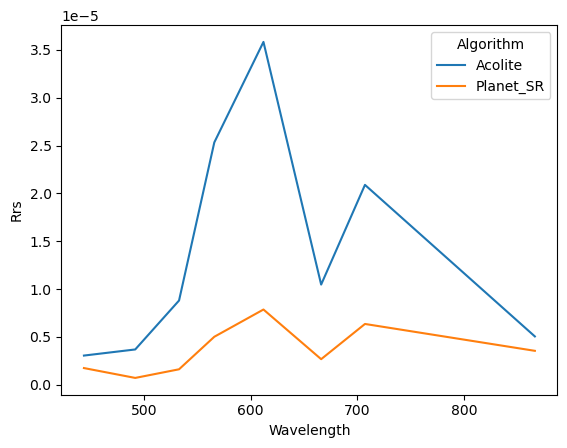

In [113]:
sns.lineplot(data=pd.DataFrame(diffd_multi_o).groupby(['Wavelength', 'Algorithm']).mean().reset_index(),
             x='Wavelength', y='Rrs', hue='Algorithm')

In [100]:
0.011559 - 0.008626

0.002933

In [124]:
dalec_sd_melt.date.dt.year

0      2022
1      2022
2      2022
3      2023
4      2023
       ... 
283    2023
284    2023
285    2023
286    2023
287    2023
Name: date, Length: 288, dtype: int32

In [125]:
dalec_sd_melt[(dalec_sd_melt.Wavelength==444) & (dalec_sd_melt.date.dt.year==2022)]

,Rrs_DALEC,Wavelength,date,date_flag,original_date,Date,Sat_ID,Algorithm,Rrs,Multiple_overpass_day
0,0.004061,444.0,2022-08-10,0.0,nan,2022-08-10 10:27:06+00:00,2432,Acolite,0.004927,False
1,0.003798,444.0,2022-08-11,0.0,nan,2022-08-11 10:28:22+00:00,2427,Acolite,0.004054,False
2,0.003795,444.0,2022-08-13,0.0,nan,2022-08-13 11:13:41+00:00,227a,Acolite,0.005004,False
144,0.004061,444.0,2022-08-10,0.0,nan,2022-08-10 10:27:06+00:00,2432,Planet_SR,0.003288,False
145,0.003798,444.0,2022-08-11,0.0,nan,2022-08-11 10:28:22+00:00,2427,Planet_SR,0.002983,False
146,0.003795,444.0,2022-08-13,0.0,nan,2022-08-13 11:13:41+00:00,227a,Planet_SR,0.006851,False


In [89]:
dalec_sd_melt[(dalec_sd_melt.Multiple_overpass_day==True) & (dalec_sd_melt.Algorithm=='Acolite')\
              & (dalec_sd_melt.Wavelength==444)]

,Rrs_DALEC,Wavelength,date,date_flag,original_date,Date,Sat_ID,Algorithm,Rrs,Multiple_overpass_day
4,0.000402,444.0,2023-07-12,0.0,nan,2023-07-12 11:05:26+00:00,248c,Acolite,0.011559,True
5,0.000402,444.0,2023-07-12,0.0,nan,2023-07-12 10:31:47+00:00,24bf,Acolite,0.008626,True
6,0.000420,444.0,2023-07-21,0.0,nan,2023-07-21 10:34:38.500000+00:00,24b3,Acolite,0.009167,True
7,0.000420,444.0,2023-07-21,0.0,nan,2023-07-21 10:35:46+00:00,24c4,Acolite,0.008564,True
11,0.002089,444.0,2023-09-07,0.0,nan,2023-09-07 10:30:39+00:00,2448,Acolite,0.008650,True
12,0.002089,444.0,2023-09-07,0.0,nan,2023-09-07 11:11:45+00:00,247f,Acolite,0.007629,True
15,0.000572,444.0,2023-09-12,0.0,nan,2023-09-12 10:32:01+00:00,2415,Acolite,0.006528,True
16,0.000572,444.0,2023-09-12,0.0,nan,2023-09-12 11:11:16+00:00,2475,Acolite,0.007993,True


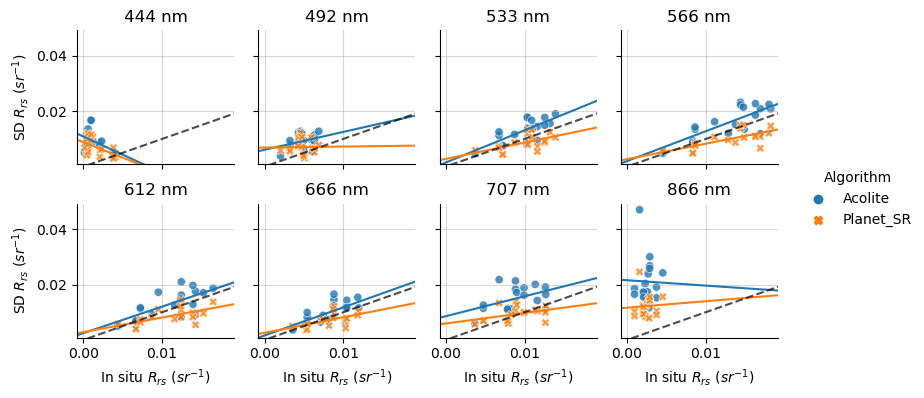

In [117]:
# g = sns.lmplot(data=dalec_sd_melt, x='Rrs_DALEC', y='Rrs',
#                hue='Algorithm', col='Wavelength', col_wrap=2,
#               facet_kws={'sharey':True, 'sharex':True},
#                ci=None,
#                height=2.5)

g = sns.relplot(data=dalec_sd_melt, x='Rrs_DALEC', y='Rrs',
                hue='Algorithm', col='Wavelength', col_wrap=4,
                style='Algorithm',
                facet_kws={'sharey':True, 'sharex':True},
                alpha=0.8,
                height=2.)

def annotate(data, x='Rrs_DALEC', y='Rrs', order=1, plot=True, lims=None, **kws):
    for alg, color in zip(data.Algorithm.unique(), sns.color_palette()):
        data_in = data[data.Algorithm==alg]
        res = sp.stats.linregress(data_in.dropna()[x]**order, data_in.dropna()[y])
        ax = plt.gca()
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        m = res.slope
        c = res.intercept
        if plot:
            ax.plot(xlim, (np.array(xlim) * m) + c, color=color)
            ax.set_xlim(xlim[0], xlim[1])
            ax.set_ylim(ylim[0], ylim[1])
    
g.map_dataframe(annotate)


# g.map_dataframe(sns.lmplot, x='Rrs_DALEC', y='Rrs',
#                 ci=None, scatter=False, hue='Algorithm')

titles = ['444 nm', '492 nm', '533 nm', '566 nm', '612 nm', '666 nm', '707 nm', '866 nm']

for ax, title in zip(g.axes.flat[:], titles):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lims = [np.min([xlim, ylim]), np.max([xlim, ylim])]
    ax.plot(lims, lims, 'k--', alpha=0.7)
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.grid(alpha=0.5)
    ax.set_xlabel('In situ $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('SD $R_{rs}$ ($sr^{-1}$)')
    ax.set_title(title)
    
plt.savefig('figures_for_paper/SD_atmos_corr.svg', dpi=300)

    
# plt.tight_layout()

In [41]:
def r2_rmse(g):
    try:
        r2 = sp.stats.pearsonr(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])[0]**2
        slope = sp.stats.linregress(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs']).slope
        rmse = RMSE(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        mape = MAPE(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        mrd = MRD(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        mae = mean_absolute_error(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        mdae = median_absolute_error(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        mapd = MAPD(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        mdsa = MDSA(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        mavd = MAvD(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        sspb = SSPB(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        pbias = P_BIAS(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        
        return pd.Series(dict(r2 = r2,
                              slope=slope,
                              mapd = mapd,
                              mdsa=mdsa,
                              mavd=mavd,
                              sspb=sspb,
                              mae=mae,
                              mdae = mdae,
                              rmse = rmse,
                              mape=mape,
                              mrd=mrd,
                              pbias=pbias,
                                        ))
    except ValueError:
        return pd.Series(dict(r2 = np.nan,
                              slope=np.nan, 
                              mapd = np.nan,
                              mdsa=np.nan,
                              mavd=np.nan,
                              sspb=np.nan,
                              mae=np.nan,
                              mdae=np.nan,
                              rmse = np.nan,
                              mape=np.nan,
                              mrd=np.nan,
                              pbias=np.nan,
                                          ))

In [42]:
metrics = dalec_sd_melt.groupby(['Wavelength', 'Algorithm']).apply(r2_rmse).reset_index()

In [43]:
# metrics.to_csv('SD_atmos_corr_metrics_out_5_jun___+876.csv')

In [44]:
metrics

,Wavelength,Algorithm,r2,slope,mapd,mdsa,mavd,sspb,mae,mdae,rmse,mape,mrd,pbias
0,444.0,Acolite,0.216929,-1.312191,1284.102456,1284.039110,0.007594,1284.039110,0.007594,0.007642,0.008732,1313.482075,13.134821,-1313.482075
1,444.0,Planet_SR,0.218927,-1.118710,875.467473,874.851772,0.005814,874.851772,0.005990,0.004990,0.006942,1145.860458,11.413624,-1141.362437
2,492.0,Acolite,0.068651,0.644932,89.955918,89.952436,0.004373,89.952436,0.004507,0.004575,0.005232,100.849061,0.985125,-98.512496
3,492.0,Planet_SR,0.000260,0.036624,60.101174,69.141371,0.002219,59.702220,0.002970,0.002293,0.003692,71.418732,0.569825,-56.982504
4,533.0,Acolite,0.556300,1.162642,29.120616,29.058848,0.003100,29.058848,0.003536,0.002899,0.004146,36.176818,0.321960,-32.195983
5,533.0,Planet_SR,0.312847,0.590101,23.662541,29.410984,-0.001288,-16.489894,0.002360,0.002413,0.002839,24.368777,-0.097506,9.750566
6,566.0,Acolite,0.588947,1.077641,24.228447,24.227488,0.003028,18.981981,0.003841,0.004239,0.004642,29.036096,0.239292,-23.929203
7,566.0,Planet_SR,0.460176,0.558135,27.423106,37.839270,-0.003136,-37.839270,0.003349,0.003404,0.004282,24.434782,-0.211026,21.102555
8,612.0,Acolite,0.474039,0.958625,21.772276,21.763774,0.001986,14.068342,0.003161,0.002909,0.003996,28.794237,0.198749,-19.874911
9,612.0,Planet_SR,0.376163,0.526552,29.906432,35.905703,-0.002426,-30.371194,0.002982,0.002713,0.003733,25.927186,-0.187106,18.710572


In [45]:
metrics['r2_1'] = 1 - metrics.r2
metrics['slope_1'] = np.abs(1 - metrics.slope)
metrics['mard'] = np.abs(metrics.mrd)
metrics['abs_mavd'] = np.abs(metrics.mavd)
metrics['abs_sspb'] = np.abs(metrics.sspb)
metrics['abs_pbias'] = np.abs(metrics.pbias)

In [46]:
for metr in ['r2_1', 'slope_1',
             'mae', 'mdsa',
             'mapd', 'mdae',
             'rmse', 'mape',
             'mard', 'abs_mavd',
             'abs_sspb', 'abs_pbias']:
    metrics[metr+'_rank'] = metrics.groupby(['Wavelength',])[metr].rank('min')

metrics

metrics['rank_total'] = metrics[['r2_1_rank',
                                 'slope_1_rank',
                                 'mapd_rank',
                                 'rmse_rank',
                                 'abs_mavd_rank'
                                ]].sum(axis=1)

In [47]:
metrics.groupby(["Algorithm"]).rank_total.sum()

Algorithm
Acolite      63.0
Planet_SR    57.0
Name: rank_total, dtype: float64

In [48]:
metrics[(metrics['Wavelength']!=866)].groupby(["Algorithm"]).rank_total.sum()

Algorithm
Acolite      53.0
Planet_SR    52.0
Name: rank_total, dtype: float64

In [49]:
metrics[metrics.Algorithm=='Acolite'].rank_total.sum()

63.0

In [50]:
metrics[metrics.Algorithm=='Acolite']

,Wavelength,Algorithm,r2,slope,mapd,mdsa,mavd,sspb,mae,mdae,...,mdsa_rank,mapd_rank,mdae_rank,rmse_rank,mape_rank,mard_rank,abs_mavd_rank,abs_sspb_rank,abs_pbias_rank,rank_total
0,444.0,Acolite,0.216929,-1.312191,1284.102456,1284.039110,0.007594,1284.039110,0.007594,0.007642,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0
2,492.0,Acolite,0.068651,0.644932,89.955918,89.952436,0.004373,89.952436,0.004507,0.004575,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,8.0
4,533.0,Acolite,0.556300,1.162642,29.120616,29.058848,0.003100,29.058848,0.003536,0.002899,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,8.0
6,566.0,Acolite,0.588947,1.077641,24.228447,24.227488,0.003028,18.981981,0.003841,0.004239,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,6.0
8,612.0,Acolite,0.474039,0.958625,21.772276,21.763774,0.001986,14.068342,0.003161,0.002909,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,6.0
10,666.0,Acolite,0.447936,1.017418,19.832227,19.832114,0.001744,16.422762,0.002419,0.001413,...,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,7.0
12,707.0,Acolite,0.196176,0.719266,64.136990,64.132374,0.006078,64.132374,0.006263,0.006360,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,8.0
14,866.0,Acolite,0.000487,-0.194203,742.812715,742.719118,0.018580,742.719118,0.018580,0.015470,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0


In [51]:
best_ranks = metrics.dropna().groupby('Wavelength')['rank_total'].idxmin()
metrics.loc[best_ranks]

,Wavelength,Algorithm,r2,slope,mapd,mdsa,mavd,sspb,mae,mdae,...,mdsa_rank,mapd_rank,mdae_rank,rmse_rank,mape_rank,mard_rank,abs_mavd_rank,abs_sspb_rank,abs_pbias_rank,rank_total
1,444.0,Planet_SR,0.218927,-1.118710,875.467473,874.851772,0.005814,874.851772,0.005990,0.004990,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0
3,492.0,Planet_SR,0.000260,0.036624,60.101174,69.141371,0.002219,59.702220,0.002970,0.002293,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0
5,533.0,Planet_SR,0.312847,0.590101,23.662541,29.410984,-0.001288,-16.489894,0.002360,0.002413,...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0
6,566.0,Acolite,0.588947,1.077641,24.228447,24.227488,0.003028,18.981981,0.003841,0.004239,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,6.0
8,612.0,Acolite,0.474039,0.958625,21.772276,21.763774,0.001986,14.068342,0.003161,0.002909,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,6.0
10,666.0,Acolite,0.447936,1.017418,19.832227,19.832114,0.001744,16.422762,0.002419,0.001413,...,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,7.0
13,707.0,Planet_SR,0.148059,0.383065,22.876154,29.688872,0.000446,-0.830423,0.002259,0.001952,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0
15,866.0,Planet_SR,0.002869,0.235192,393.326145,393.286705,0.009717,393.286705,0.009717,0.009613,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0


In [52]:
metrics.groupby(['Algorithm', 'Wavelength']).r2_1_rank.mean()

Algorithm  Wavelength
Acolite    444.0         2.0
           492.0         1.0
           533.0         1.0
           566.0         1.0
           612.0         1.0
           666.0         1.0
           707.0         1.0
           866.0         2.0
Planet_SR  444.0         1.0
           492.0         2.0
           533.0         2.0
           566.0         2.0
           612.0         2.0
           666.0         2.0
           707.0         2.0
           866.0         1.0
Name: r2_1_rank, dtype: float64

In [53]:
# find best rmse algs
metrics.loc[metrics.groupby('Wavelength').rmse.agg('idxmin')]

,Wavelength,Algorithm,r2,slope,mapd,mdsa,mavd,sspb,mae,mdae,...,mdsa_rank,mapd_rank,mdae_rank,rmse_rank,mape_rank,mard_rank,abs_mavd_rank,abs_sspb_rank,abs_pbias_rank,rank_total
1,444.0,Planet_SR,0.218927,-1.118710,875.467473,874.851772,0.005814,874.851772,0.005990,0.004990,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0
3,492.0,Planet_SR,0.000260,0.036624,60.101174,69.141371,0.002219,59.702220,0.002970,0.002293,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0
5,533.0,Planet_SR,0.312847,0.590101,23.662541,29.410984,-0.001288,-16.489894,0.002360,0.002413,...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0
7,566.0,Planet_SR,0.460176,0.558135,27.423106,37.839270,-0.003136,-37.839270,0.003349,0.003404,...,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,9.0
9,612.0,Planet_SR,0.376163,0.526552,29.906432,35.905703,-0.002426,-30.371194,0.002982,0.002713,...,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,9.0
11,666.0,Planet_SR,0.300245,0.561221,26.640913,33.320691,-0.001046,-12.843340,0.002015,0.001683,...,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,8.0
13,707.0,Planet_SR,0.148059,0.383065,22.876154,29.688872,0.000446,-0.830423,0.002259,0.001952,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0
15,866.0,Planet_SR,0.002869,0.235192,393.326145,393.286705,0.009717,393.286705,0.009717,0.009613,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0


In [54]:
# find best mape algs 
metrics.loc[metrics.groupby('Wavelength').mape.agg('idxmin')]

,Wavelength,Algorithm,r2,slope,mapd,mdsa,mavd,sspb,mae,mdae,...,mdsa_rank,mapd_rank,mdae_rank,rmse_rank,mape_rank,mard_rank,abs_mavd_rank,abs_sspb_rank,abs_pbias_rank,rank_total
1,444.0,Planet_SR,0.218927,-1.118710,875.467473,874.851772,0.005814,874.851772,0.005990,0.004990,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0
3,492.0,Planet_SR,0.000260,0.036624,60.101174,69.141371,0.002219,59.702220,0.002970,0.002293,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0
5,533.0,Planet_SR,0.312847,0.590101,23.662541,29.410984,-0.001288,-16.489894,0.002360,0.002413,...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0
7,566.0,Planet_SR,0.460176,0.558135,27.423106,37.839270,-0.003136,-37.839270,0.003349,0.003404,...,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,9.0
9,612.0,Planet_SR,0.376163,0.526552,29.906432,35.905703,-0.002426,-30.371194,0.002982,0.002713,...,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,9.0
11,666.0,Planet_SR,0.300245,0.561221,26.640913,33.320691,-0.001046,-12.843340,0.002015,0.001683,...,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,8.0
13,707.0,Planet_SR,0.148059,0.383065,22.876154,29.688872,0.000446,-0.830423,0.002259,0.001952,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0
15,866.0,Planet_SR,0.002869,0.235192,393.326145,393.286705,0.009717,393.286705,0.009717,0.009613,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0


In [55]:
# find best r2 algs 
metrics.loc[metrics.groupby('Wavelength').r2.agg('idxmax')]

,Wavelength,Algorithm,r2,slope,mapd,mdsa,mavd,sspb,mae,mdae,...,mdsa_rank,mapd_rank,mdae_rank,rmse_rank,mape_rank,mard_rank,abs_mavd_rank,abs_sspb_rank,abs_pbias_rank,rank_total
1,444.0,Planet_SR,0.218927,-1.118710,875.467473,874.851772,0.005814,874.851772,0.005990,0.004990,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0
2,492.0,Acolite,0.068651,0.644932,89.955918,89.952436,0.004373,89.952436,0.004507,0.004575,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,8.0
4,533.0,Acolite,0.556300,1.162642,29.120616,29.058848,0.003100,29.058848,0.003536,0.002899,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,8.0
6,566.0,Acolite,0.588947,1.077641,24.228447,24.227488,0.003028,18.981981,0.003841,0.004239,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,6.0
8,612.0,Acolite,0.474039,0.958625,21.772276,21.763774,0.001986,14.068342,0.003161,0.002909,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,6.0
10,666.0,Acolite,0.447936,1.017418,19.832227,19.832114,0.001744,16.422762,0.002419,0.001413,...,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,7.0
12,707.0,Acolite,0.196176,0.719266,64.136990,64.132374,0.006078,64.132374,0.006263,0.006360,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,8.0
15,866.0,Planet_SR,0.002869,0.235192,393.326145,393.286705,0.009717,393.286705,0.009717,0.009613,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0


## looks like planet SR product generally gets better errors, but worse R^2 than acolite...

- possible a hybrid approach would work quite well...
- select the best algorithm per wavelength

In [56]:
SD_SR_total = SD_SR_melt.drop(['location', 'Sat_ID'], axis=1).groupby([#'Date',
                                                                       'date',
                                                                       'Wavelength',]).median()
SD_SR_total.rename(columns={'Rrs':'Planet_SR'}, inplace=True)
SD_SR_total = SD_SR_total.reset_index()

SD_acolite_total = SD_acolite_melt.drop(['location', 'Sat_ID'],
                                         axis=1).groupby([#'Date',
                                         'date',
                                         'Wavelength']).median()

SD_acolite_total.rename(columns={'Rrs':'Acolite'}, inplace=True)
SD_acolite_total = SD_acolite_total.reset_index()

In [57]:
SD_SR_total

,date,Wavelength,Date,Planet_SR
0,2020-04-07,444.0,2020-04-07 10:35:46+00:00,0.006645
1,2020-04-07,492.0,2020-04-07 10:35:46+00:00,0.006409
2,2020-04-07,533.0,2020-04-07 10:35:46+00:00,0.006912
3,2020-04-07,566.0,2020-04-07 10:35:46+00:00,0.006668
4,2020-04-07,612.0,2020-04-07 10:35:46+00:00,0.006592
...,...,...,...,...
1515,2024-04-08,566.0,2024-04-08 11:33:11+00:00,0.010239
1516,2024-04-08,612.0,2024-04-08 11:33:11+00:00,0.009644
1517,2024-04-08,666.0,2024-04-08 11:33:11+00:00,0.009293
1518,2024-04-08,707.0,2024-04-08 11:33:11+00:00,0.01088


In [58]:
on_cols = ['date', 'Wavelength', 'Date',]

SD_total = SD_SR_total.merge(SD_acolite_total, on=on_cols)

In [59]:
SD_total

,date,Wavelength,Date,Planet_SR,Acolite
0,2020-04-07,444.0,2020-04-07 10:35:46+00:00,0.006645,0.006075
1,2020-04-07,492.0,2020-04-07 10:35:46+00:00,0.006409,0.006498
2,2020-04-07,533.0,2020-04-07 10:35:46+00:00,0.006912,0.007883
3,2020-04-07,566.0,2020-04-07 10:35:46+00:00,0.006668,0.007561
4,2020-04-07,612.0,2020-04-07 10:35:46+00:00,0.006592,0.007404
...,...,...,...,...,...
1515,2024-04-08,566.0,2024-04-08 11:33:11+00:00,0.010239,0.007441
1516,2024-04-08,612.0,2024-04-08 11:33:11+00:00,0.009644,0.006644
1517,2024-04-08,666.0,2024-04-08 11:33:11+00:00,0.009293,0.00717
1518,2024-04-08,707.0,2024-04-08 11:33:11+00:00,0.01088,0.012146


In [60]:
SD_total['best_alg'] = ''
for Wavelength, alg in zip(metrics.loc[best_ranks].Wavelength,
                           metrics.loc[best_ranks].Algorithm): 
    print(Wavelength)

    SD_total.loc[SD_total.Wavelength==Wavelength, 'best_alg'] = alg

444.0
492.0
533.0
566.0
612.0
666.0
707.0
866.0


In [61]:
def get_best(df):
    return df[df['best_alg']]

In [62]:
SD_total['Rrs_best'] = SD_total.apply(get_best, axis=1)

In [63]:
SD_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   date        1520 non-null   object             
 1   Wavelength  1520 non-null   float64            
 2   Date        1520 non-null   datetime64[ns, UTC]
 3   Planet_SR   1520 non-null   object             
 4   Acolite     1520 non-null   object             
 5   best_alg    1520 non-null   object             
 6   Rrs_best    1520 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(2), object(4)
memory usage: 83.2+ KB


In [64]:
# SD_total.to_csv('Superdoves_best_atmos_corr_med_56.147005__3.923311_24_jun.csv')

In [65]:
metrics

,Wavelength,Algorithm,r2,slope,mapd,mdsa,mavd,sspb,mae,mdae,...,mdsa_rank,mapd_rank,mdae_rank,rmse_rank,mape_rank,mard_rank,abs_mavd_rank,abs_sspb_rank,abs_pbias_rank,rank_total
0,444.0,Acolite,0.216929,-1.312191,1284.102456,1284.039110,0.007594,1284.039110,0.007594,0.007642,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0
1,444.0,Planet_SR,0.218927,-1.118710,875.467473,874.851772,0.005814,874.851772,0.005990,0.004990,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0
2,492.0,Acolite,0.068651,0.644932,89.955918,89.952436,0.004373,89.952436,0.004507,0.004575,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,8.0
3,492.0,Planet_SR,0.000260,0.036624,60.101174,69.141371,0.002219,59.702220,0.002970,0.002293,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0
4,533.0,Acolite,0.556300,1.162642,29.120616,29.058848,0.003100,29.058848,0.003536,0.002899,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,8.0
5,533.0,Planet_SR,0.312847,0.590101,23.662541,29.410984,-0.001288,-16.489894,0.002360,0.002413,...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0
6,566.0,Acolite,0.588947,1.077641,24.228447,24.227488,0.003028,18.981981,0.003841,0.004239,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,6.0
7,566.0,Planet_SR,0.460176,0.558135,27.423106,37.839270,-0.003136,-37.839270,0.003349,0.003404,...,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,9.0
8,612.0,Acolite,0.474039,0.958625,21.772276,21.763774,0.001986,14.068342,0.003161,0.002909,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,6.0
9,612.0,Planet_SR,0.376163,0.526552,29.906432,35.905703,-0.002426,-30.371194,0.002982,0.002713,...,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,9.0


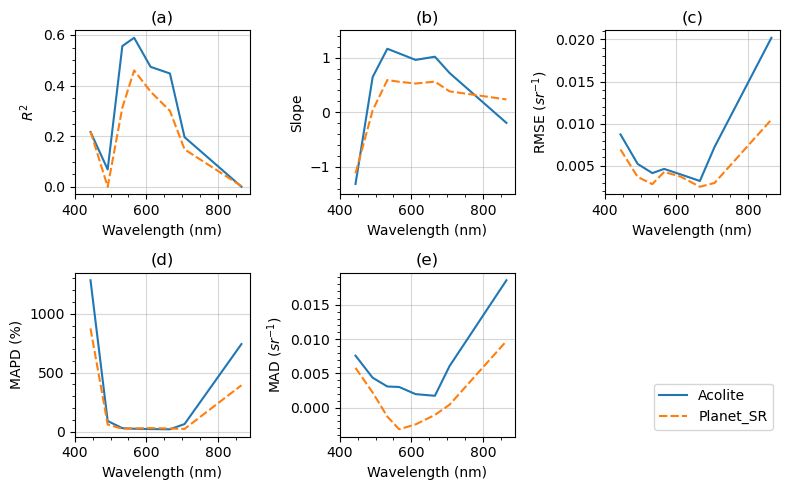

In [66]:
fig, axs = plt.subplots(2, 3, figsize=(8, 5), sharex=False)
ORD = ['Acolite', 'Planet_SR']

metrs = ['r2', 'slope', 'rmse', 'mapd', 'mavd']
metrs_labels = ['$R^2$', 'Slope', 'RMSE ($sr^{-1}$)', 'MAPD (%)', 'MAD ($sr^{-1}$)']

for ax, met in zip(axs.flatten(), metrs):
    sns.lineplot(data=metrics, x='Wavelength', y=met, hue='Algorithm', style='Algorithm',
                 ax=ax, legend=False, hue_order=ORD)

axs.flatten()[-1].set_axis_off()
# axs.flatten()[3].set_ylim(0, 150)
axs.flatten()[1].set_ylim(-1.5, 1.5)


axs.flatten()[-1].legend(axs.flatten()[-2].get_lines(), ORD,
                         loc='lower right')

for ax, lab, titl in zip(axs.flatten(), metrs_labels, ['(a)', '(b)', '(c)', '(d)', '(e)']):
    ax.minorticks_on()
    ax.grid(alpha=0.5)
    ax.set_ylabel(lab)
    ax.set_xlim(400, 890)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_title(titl)


    
plt.tight_layout()
# plt.savefig('figures_for_paper/SD_atmos_corr_metrics.svg', dpi=300)


In [67]:
S2_metrics = pd.read_csv('S2_atmos_corr_metrics_out_20m__sdf.csv')

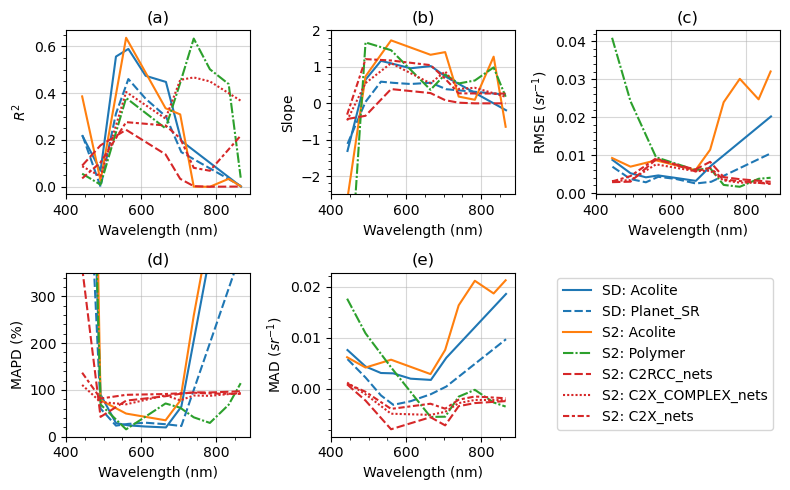

In [77]:
fig, axs = plt.subplots(2, 3, figsize=(8, 5), sharex=False)
ORD_planet = ['Acolite', 'Planet_SR']
ORD_S2 = ['Acolite', 'Polymer', 'C2RCC_nets',
          'C2X_COMPLEX_nets', 'C2X_nets']

labels = ['SD: Acolite', 'SD: Planet_SR', 'S2: Acolite', 'S2: Polymer', 'S2: C2RCC_nets',
          'S2: C2X_COMPLEX_nets', 'S2: C2X_nets']

metrs = ['r2', 'slope', 'rmse', 'mapd', 'mavd']
metrs_labels = ['$R^2$', 'Slope', 'RMSE ($sr^{-1}$)', 'MAPD (%)', 'MAD ($sr^{-1}$)']

for ax, met in zip(axs.flatten(), metrs):
    sns.lineplot(data=metrics, x='Wavelength', y=met, hue='Algorithm', style='Algorithm',
                 ax=ax, legend=False, hue_order=ORD_planet, palette=[sns.color_palette()[0],
                                                                     sns.color_palette()[0]])
    
for ax, met in zip(axs.flatten(), metrs):
    sns.lineplot(data=S2_metrics, x='Wavelength', y=met, hue='Algorithm', style='Algorithm',
                 ax=ax, legend=False,palette=sns.color_palette()[1:3]+[sns.color_palette()[3] for i in range(3)],
                 hue_order=ORD_S2)

axs.flatten()[-1].set_axis_off()
axs.flatten()[3].set_ylim(0, 350)
axs.flatten()[1].set_ylim(-2.5, 2)



axs.flatten()[-1].legend(axs.flatten()[-2].get_lines(), labels,
                         loc='lower right')

for ax, lab, titl in zip(axs.flatten(), metrs_labels, ['(a)', '(b)', '(c)', '(d)', '(e)']):
    ax.minorticks_on()
    ax.grid(alpha=0.5)
    ax.set_ylabel(lab)
    ax.set_xlim(400, 890)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_title(titl)


    
plt.tight_layout()
plt.savefig('figures_for_paper/SD_S2_atmos_corr_metrics.svg', dpi=300)
